In [2]:
"""
Morphology para la limpieza de máscaras
Este notebook presenta operaciones basic morphological para la limpieza de máscaras binarias.
Tras el thresholding, las máscaras binarias suelen contener pequeñas regiones ruidosas, agujeros, bordes irregulares o estructuras fusionadas. Las operaciones morfológicas ayudan a refinar estas máscaras y a mejorar la calidad del análisis posterior.
Objetivos de aprendizaje
- Comprender la finalidad de la morfología binaria
- Aplicar erosión, dilatación, apertura y cierre
- Interpretar el efecto del tamaño de los elementos de estructuración
- Utilizar la morfología para limpiar máscaras basadas en thresholding
- Reconocer el papel de la morphology en los flujos de trabajo de segmentación
Contexto de la imagenes de objetos
La limpieza morfológica se utiliza ampliamente en la imagen científica para:
- Eliminar el ruido aislado tras la thresholding
- Rellenar pequeños agujeros en regiones segmentadas
- Suavizar los bordes de los objetos
- Preparar máscaras para el análisis de componentes conectados
- Mejorar las mediciones de porosidad y partículas
"""

'\nMorphology para la limpieza de máscaras\nEste notebook presenta operaciones basic morphological para la limpieza de máscaras binarias.\nTras el thresholding, las máscaras binarias suelen contener pequeñas regiones ruidosas, agujeros, bordes irregulares o estructuras fusionadas. Las operaciones morfológicas ayudan a refinar estas máscaras y a mejorar la calidad del análisis posterior.\nObjetivos de aprendizaje\n- Comprender la finalidad de la morfología binaria\n- Aplicar erosión, dilatación, apertura y cierre\n- Interpretar el efecto del tamaño de los elementos de estructuración\n- Utilizar la morfología para limpiar máscaras basadas en thresholding\n- Reconocer el papel de la morphology en los flujos de trabajo de segmentación\nContexto de la imagenes de objetos\nLa limpieza morfológica se utiliza ampliamente en la imagen científica para:\n- Eliminar el ruido aislado tras la thresholding\n- Rellenar pequeños agujeros en regiones segmentadas\n- Suavizar los bordes de los objetos\n- 

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, filters, morphology, util
from skimage.draw import disk, rectangle

In [4]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

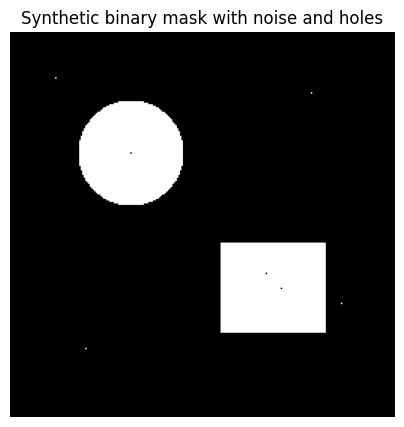

In [7]:
# Create a synthetic binary mask with defects
mask = np.zeros((256, 256), dtype=bool)

rr, cc = disk((80, 80), 35)
mask[rr, cc] = True

rr, cc = rectangle(start=(140, 140), extent=(60, 70), shape=mask.shape)
mask[rr, cc] = True

# Add small noisy foreground spots
mask[30, 30] = True
mask[40, 200] = True
mask[210, 50] = True
mask[180, 220] = True

# Add small holes inside objects
mask[80, 80] = False
mask[160, 170] = False
mask[170, 180] = False

show_image(mask, "Synthetic binary mask with noise and holes", save_path="../figures/figures_morphology_mask/Synthetic-binary-mask-noise-holes.png")

In [8]:
"""
Elemento estructural
Un elemento estructural define el entorno local utilizado por la operación morfológica.
Aquí comenzamos con un pequeño elemento estructurante en forma de disco.
"""
selem = morphology.disk(3)
selem

array([[0, 0, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 0],
       [1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0]], dtype=uint8)

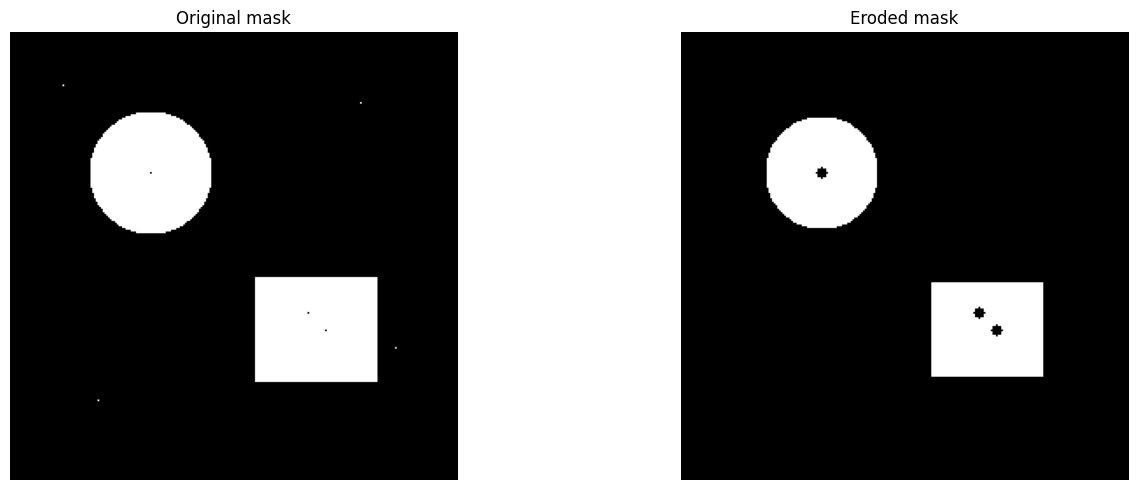

In [10]:
"""
Erosión
La erosión reduce las regiones en primer plano.
Un píxel en primer plano permanece como "Verdadero" solo si el elemento estructural se ajusta completamente al objeto que lo rodea.
Efectos típicos:
- Elimina el ruido brillante de baja intensidad
- Reduce los límites del objeto
- Puede romper conexiones finas
"""
eroded = morphology.erosion(mask, selem)

compare_images(
    [mask, eroded],
    ["Original mask", "Eroded mask"],
    save_path="../figures/figures_morphology_mask/erosion_comparison.png"
)

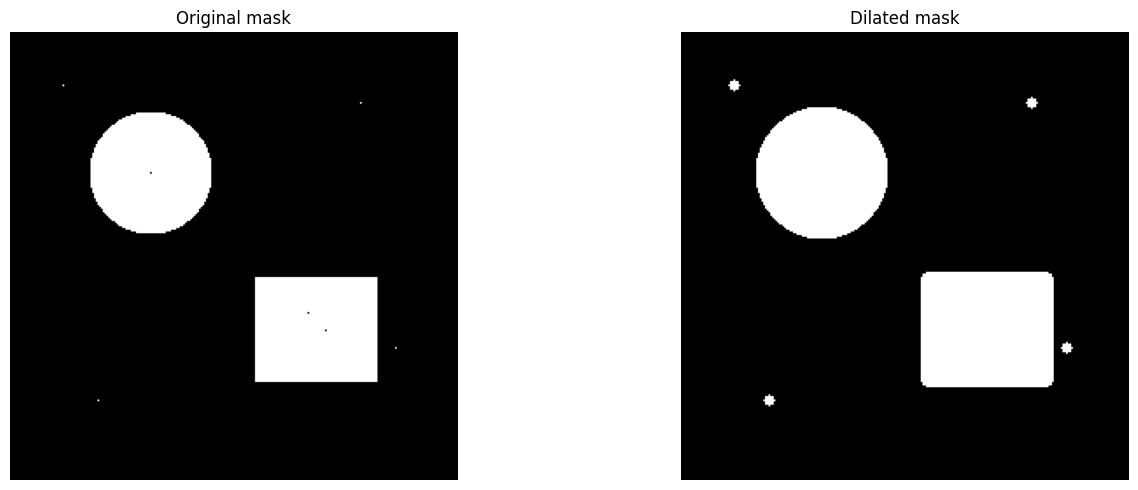

In [12]:
"""
Dilatación
La dilatación expande las regiones del primer plano.
Un píxel se vuelve "Verdadero" si el elemento estructural se superpone al primer plano.
Efectos típicos:
- Agranda objetos
- Rellena pequeños huecos
- Puede conectar regiones cercanas
"""
dilated = morphology.dilation(mask, selem)

compare_images(
    [mask, dilated],
    ["Original mask", "Dilated mask"],
    save_path="../figures/figures_morphology_mask/dilation_comparison.png"
)

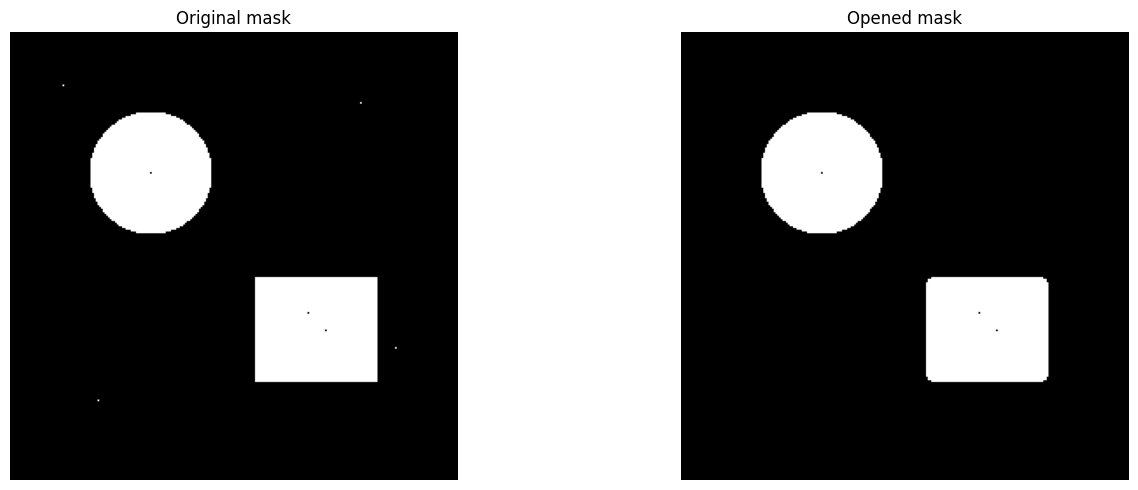

In [14]:
"""
Opening
El opening es un proceso de erosión seguido de dilatación.
Es especialmente útil para eliminar pequeños ruidos en primer plano, conservando la forma general de los objetos más grandes.
"""
opened = morphology.opening(mask, selem)

compare_images(
    [mask, opened],
    ["Original mask", "Opened mask"],
    save_path="../figures/figures_morphology_mask/opening_comparison.png"
)

In [ ]:
"""
Closing
El closing es un proceso de dilatación seguido de erosión.
Es útil para rellenar pequeños agujeros, cerrar pequeñas grietas y alisar los contornos de los objetos.
"""
closed = morphology.closing(mask, selem)

compare_images(
    [mask, closed],
    ["Original mask", "Closed mask"],
    save_path="../figures/figures_morphology_mask/closing_comparison.png"
)